© 2026 WaLSA Team - Shahin Jafarzadeh et al.

This notebook is part of the [WaLSAlib](https://github.com/WaLSAteam/WaLSAlib) package (v1.0.0), provided under the [Apache License, Version 2.0](http://www.apache.org/licenses/LICENSE-2.0).

You may use, modify, and distribute this notebook and its contents under the terms of the license.

---

**Important Note on Figures**:
Figures generated using this notebook that are **identical to or derivative of those published in**:  
**Jafarzadeh, S., Jess, D. B., Stangalini, M. et al. 2026, *Frontiers in Astronomy and Space Sciences*, in press**,  
as part of the research topic: **[Magnetohydrodynamic Motions: Daniel K. Inouye Solar Telescope’s Window into the Dynamic Sun](https://www.frontiersin.org/research-topics/71781/magnetohydrodynamic-motions-daniel-k-inouye-solar-telescopes-window-into-the-dynamic-sun)**,    
are copyrighted by ***Frontiers in Astronomy and Space Sciences***. Any reuse of such figures requires explicit permission from the journal.   

Figures that are newly created, modified, or unrelated to the published article may be used under the terms of the Apache License.

---

**Disclaimer**:
This notebook and its code are provided "as is", without warranty of any kind, express or implied. Refer to the license for more details.

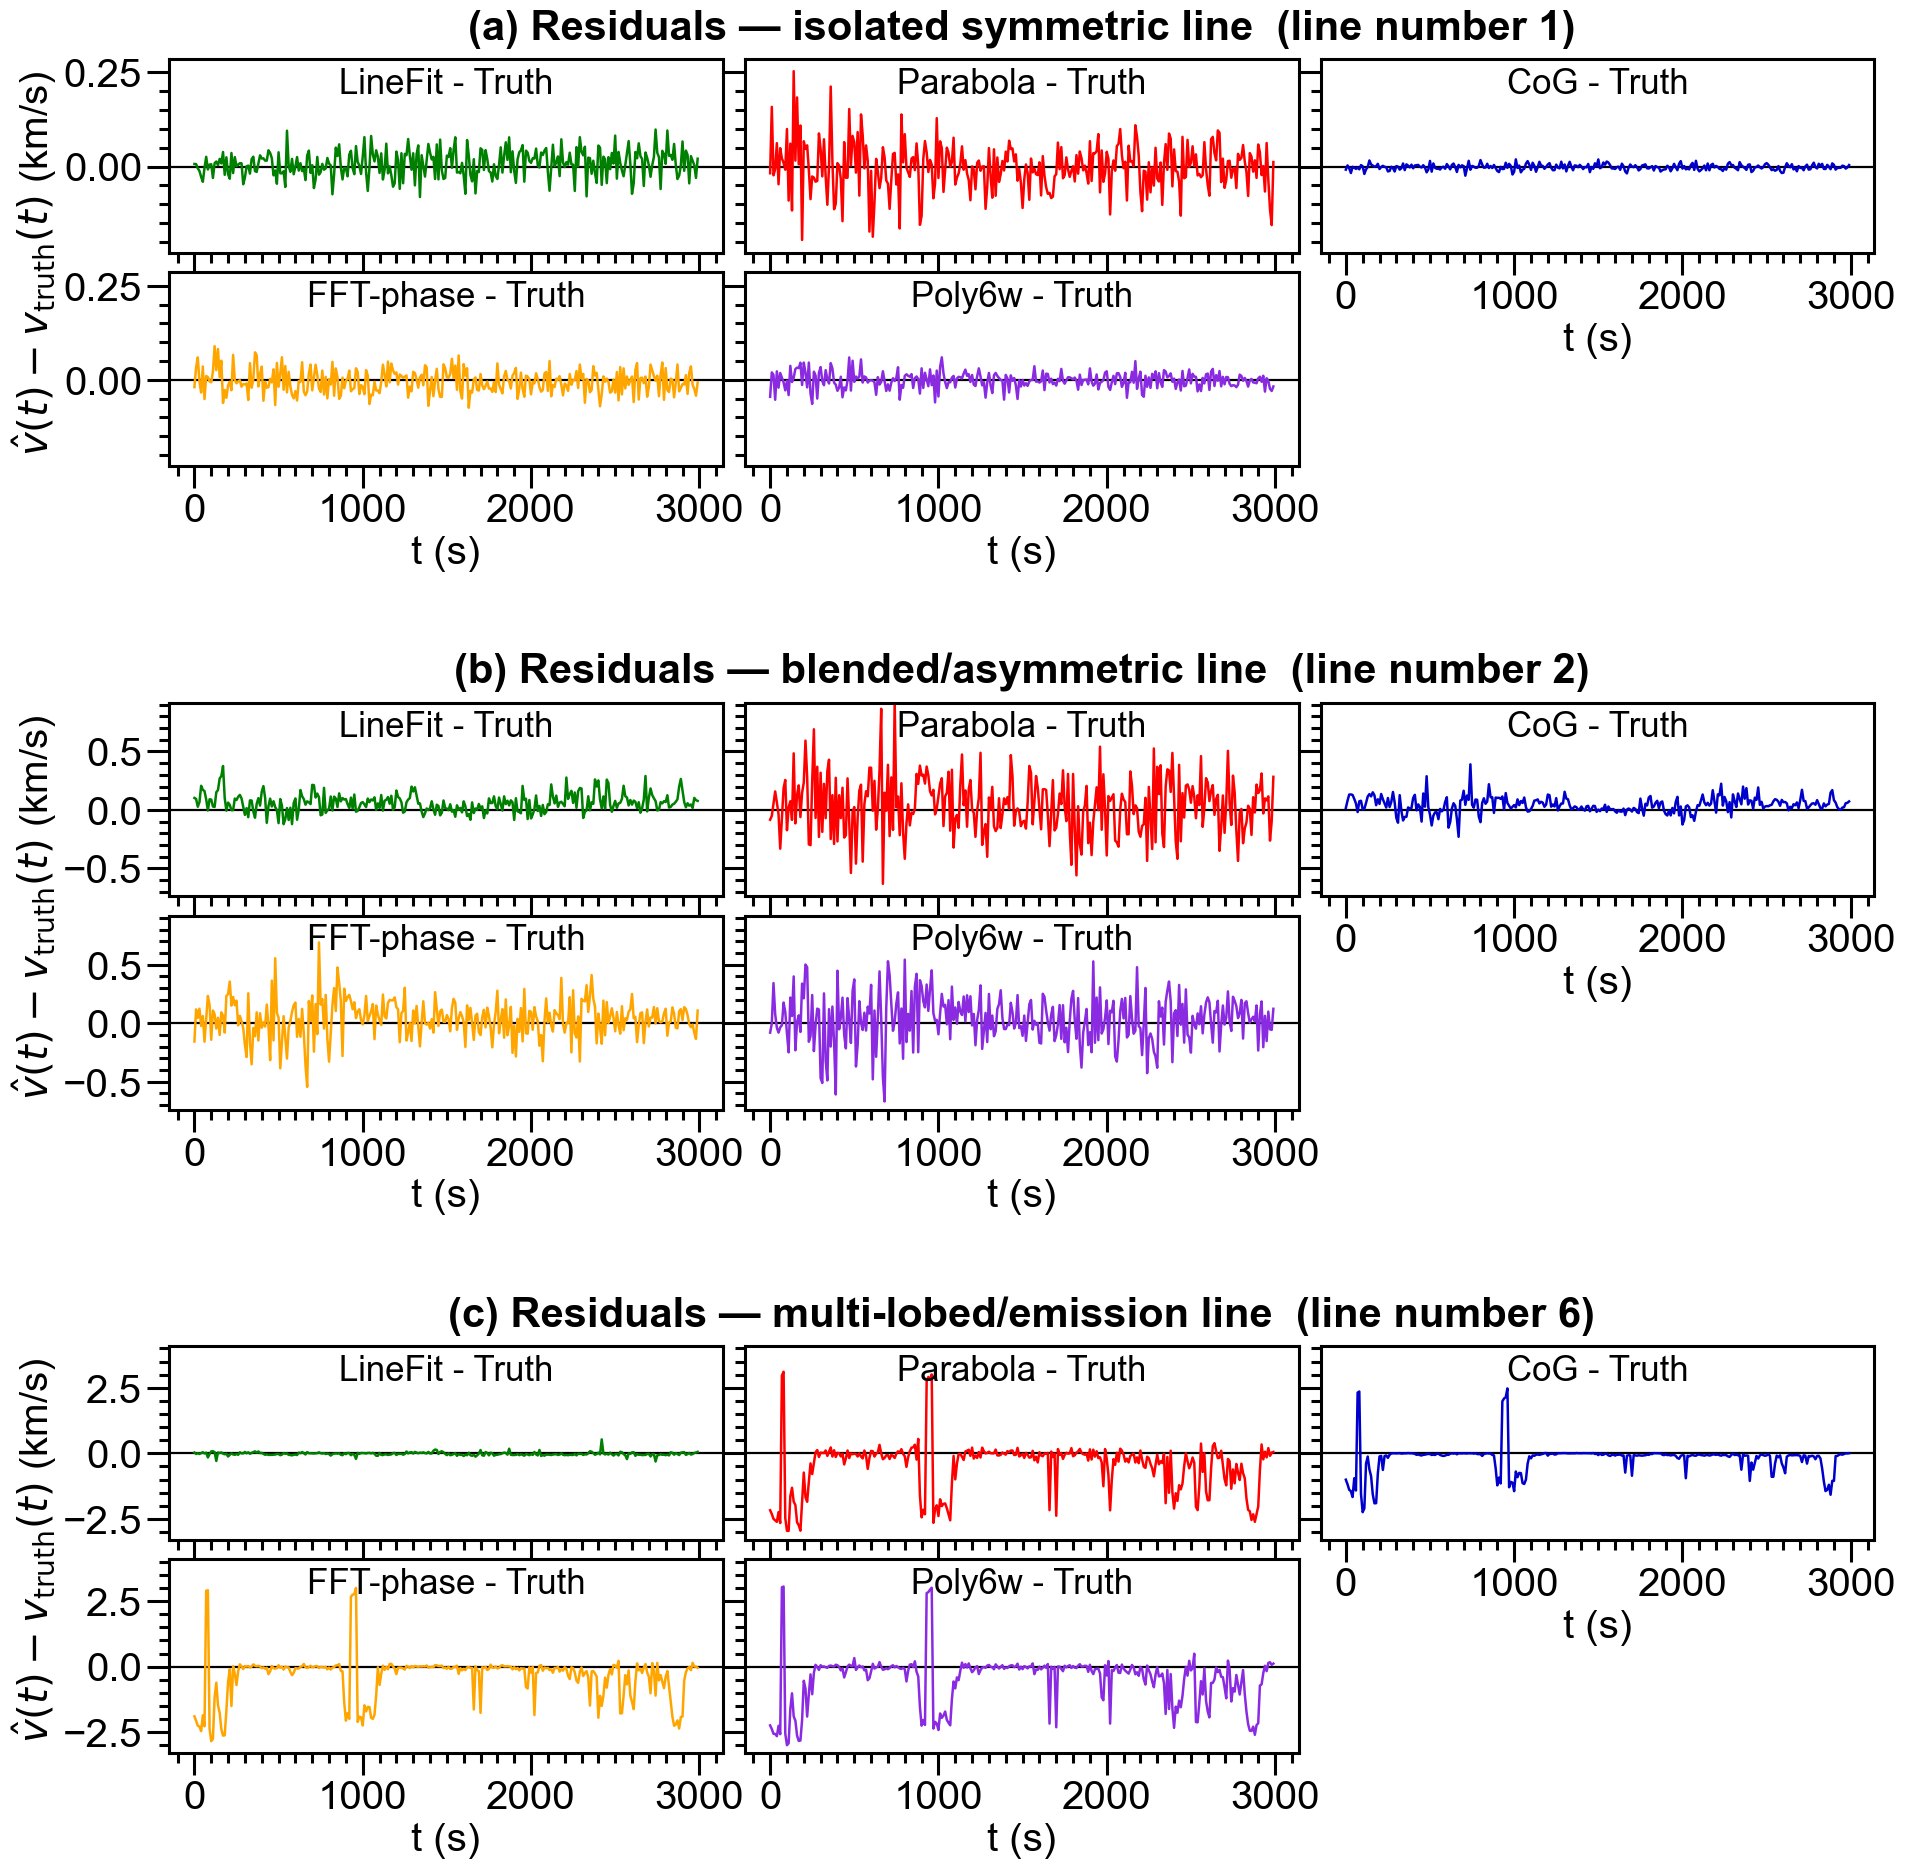

GPL Ghostscript 10.06.0 (2025-09-09)
Copyright (C) 2025 Artifex Software, Inc.  All rights reserved.
This software is supplied under the GNU AGPLv3 and comes with NO WARRANTY:
see the file COPYING for details.
Processing pages 1 through 1.
Page 1
PDF saved in CMYK format as 'Figures/FigureS1_residual_timeseries_vs_truth.pdf'
Saved: Figures/FigureS1_residual_timeseries_vs_truth.pdf
Representative lines: 1 2 6
RUN_LINEFIT_TIMESERIES: True
Manual y-limits: {0: (-0.23, 0.23), 1: (-0.74, 0.74), 5: (-3.3, 3.3)}


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Figure S1 — Residual time series versus truth for the three representative lines
================================================================================

Purpose
-------
Generate Supplementary Figure S1 showing, for the same three representative
lines used in Figure 4(a–c), the velocity residual time series

    v_method(t) - v_truth(t)

using essentially the same panel layout as Figure 4, but with:
  • residuals instead of velocities
  • the last (bottom-right) panel in each 2×3 block left empty
  • a user-controlled y-scale for each representative line

Layout
------
• 3 rows total
• each row contains a 2 × 3 block
  - top row:    LineFit, Parabola, CoG
  - bottom row: FFT-phase, Poly6w, empty
• all non-empty panels within a given row use the same y-scale

Inputs
------
Requires the same cache products used by Figure 4:

  Files/Fig4_cache/fig4_vtimeseries__t_s.npy
  Files/Fig4_cache/fig4_vtimeseries__v_true.npy
  Files/Fig4_cache/fig4_vtimeseries__v_linefit.npy
  Files/Fig4_cache/fig4_vtimeseries__v_parab.npy
  Files/Fig4_cache/fig4_vtimeseries__v_cog.npy
  Files/Fig4_cache/fig4_vtimeseries__v_fft.npy
  Files/Fig4_cache/fig4_vtimeseries__v_poly.npy
  Files/Fig4_cache/fig4_vtimeseries__meta.npz

Output
------
  Figures/FigureS1_residual_timeseries_vs_truth.pdf
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from WaLSAtools import WaLSA_save_pdf  # type: ignore

# =============================================================================
# CACHE SETTINGS
# =============================================================================
CACHE_DIR = os.path.join("Files", "Fig4_cache")
CACHE_TAG = "fig4_vtimeseries"

# =============================================================================
# USER SETTINGS
# =============================================================================
# Use the exact same representative lines as Figure 4
i_clean = 0
i_asym  = 1
i_comp  = 5

# Set y-limits manually for each representative line: (ymin, ymax)
# Units: km/s
YLIMS_BY_LINE = {
    i_clean: (-0.23, 0.23),
    i_asym:  (-0.74, 0.74),
    i_comp:  (-3.30, 3.30),
}

# =============================================================================
# Load cache
# =============================================================================
t_s        = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__t_s.npy"))
v_true     = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_true.npy"))
v_linefit  = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_linefit.npy"))
v_parab    = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_parab.npy"))
v_cog      = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_cog.npy"))
v_fft      = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_fft.npy"))
v_poly     = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_poly.npy"))

meta = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__meta.npz"), allow_pickle=True)

if "RUN_LINEFIT_TIMESERIES" in meta.files:
    RUN_LINEFIT_TIMESERIES = bool(meta["RUN_LINEFIT_TIMESERIES"])
elif "RUN_WALSA_TIMESERIES" in meta.files:
    RUN_LINEFIT_TIMESERIES = bool(meta["RUN_WALSA_TIMESERIES"])  # legacy key
else:
    RUN_LINEFIT_TIMESERIES = True

# =============================================================================
# Figure-wide style mapping from Figure 4
# =============================================================================
# METHOD_STYLES = {
#     "LineFit":   {"color": "green",      "linestyle": "--"},
#     "Parabola":  {"color": "red",        "linestyle": (0, (3, 1, 1, 1))},
#     "CoG":       {"color": "mediumblue", "linestyle": (0, (5, 2))},
#     "FFT-phase": {"color": "orange",     "linestyle": "-."},
#     "Poly6w":    {"color": "blueviolet", "linestyle": ":"},
#     "Zero":      {"color": "black",      "linestyle": "-"},
# }

METHOD_STYLES = {
    "LineFit":   {"color": "green",      "linestyle": "-"},
    "Parabola":  {"color": "red",        "linestyle": "-"},
    "CoG":       {"color": "mediumblue", "linestyle": "-"},
    "FFT-phase": {"color": "orange",     "linestyle": "-"},
    "Poly6w":    {"color": "blueviolet", "linestyle": "-"},
    "Zero":      {"color": "black",      "linestyle": "-"},
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 30,
    'axes.titlesize': 29,
    'axes.labelsize': 29,
    'xtick.labelsize': 29,
    'ytick.labelsize': 29,
    'legend.fontsize': 29,
    'figure.titlesize': 32,
    'axes.grid': False,
    'grid.alpha': 0.5,
    'grid.linestyle': '--',
    'font.weight': 500,
    'axes.titleweight': 500,
    'axes.labelweight': 500
})

plt.rc('axes', linewidth=2.2)
plt.rc('lines', linewidth=1.5)

# =============================================================================
# Residual helper
# =============================================================================
def residual(v_method, v_truth, i_line):
    return np.asarray(v_method[:, i_line] - v_truth[:, i_line], float)

# =============================================================================
# Outer Figure: 3 rows
# =============================================================================
fig = plt.figure(figsize=(22, 22))
gs_outer = fig.add_gridspec(3, 1, hspace=0.58, height_ratios=[1.15, 1.15, 1.15])

# =============================================================================
# Helper to create one row
# =============================================================================
def make_row(subspec, i_line, row_title):
    subgs = subspec.subgridspec(2, 3, wspace=0.04, hspace=0.10)

    panels = [
        ("LineFit - Truth",   "LineFit",   v_linefit if RUN_LINEFIT_TIMESERIES else None),
        ("Parabola - Truth",  "Parabola",  v_parab),
        ("CoG - Truth",       "CoG",       v_cog),
        ("FFT-phase - Truth", "FFT-phase", v_fft),
        ("Poly6w - Truth",    "Poly6w",    v_poly),
        ("",                  None,        None),   # empty panel
    ]

    if i_line not in YLIMS_BY_LINE:
        raise ValueError(f"No manual y-limits provided for line index {i_line}.")
    ylim = YLIMS_BY_LINE[i_line]

    # small headroom for inside panel titles
    yr = ylim[1] - ylim[0]
    ylim_plot = (ylim[0], ylim[1] + 0.12 * yr)

    axes = []
    for j, (title, method_name, vmat) in enumerate(panels):
        r = j // 3
        c = j % 3

        ax = fig.add_subplot(subgs[r, c])
        axes.append(ax)

        # bottom-right empty panel
        if method_name is None and vmat is None and title == "":
            ax.axis("off")
            continue

        # zero reference line
        ax.axhline(
            0.0,
            color=METHOD_STYLES["Zero"]["color"],
            linestyle=METHOD_STYLES["Zero"]["linestyle"],
            lw=1.6,
        )

        # residual curve
        if method_name == "LineFit" and (not RUN_LINEFIT_TIMESERIES or vmat is None):
            ax.text(0.04, 0.84, "LineFit not\ncomputed", transform=ax.transAxes)
        else:
            ax.plot(
                t_s,
                residual(vmat, v_true, i_line),
                color=METHOD_STYLES[method_name]["color"],
                linestyle=METHOD_STYLES[method_name]["linestyle"],
                lw=1.8,
            )

        ax.set_ylim(*ylim_plot)

        ax.text(
            0.5, 0.96, title,
            transform=ax.transAxes,
            ha="center", va="top", fontsize=25
        )

        ax.tick_params(axis="both", which="major", length=16, width=2.2)
        ax.tick_params(axis="both", which="minor", length=7, width=2.2)
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.yaxis.set_minor_locator(AutoMinorLocator(5))

        if c != 0:
            ax.set_yticklabels([])

        if r == 1 and c == 0:
            ax.set_ylabel(r"$\hat{v}(t)-v_{\rm truth}(t)$ (km/s)")
            ax.yaxis.set_label_coords(-0.20, 1.05)

        if r == 1 or (r == 0 and c == 2):
            ax.set_xlabel("t (s)")
        else:
            ax.set_xticklabels([])

    # row title centered over the 3 top panels
    row_bbox_left  = axes[0].get_position()
    row_bbox_right = axes[2].get_position()
    x_center = 0.5 * (row_bbox_left.x0 + row_bbox_right.x1)
    y_top = row_bbox_left.y1 + 0.005

    fig.text(
        x_center, y_top,
        row_title + f"  (line number {i_line+1})",
        ha="center", va="bottom", fontsize=30, fontweight="bold"
    )

# =============================================================================
# Build rows
# =============================================================================
make_row(gs_outer[0], i_clean, "(a) Residuals — isolated symmetric line")
make_row(gs_outer[1], i_asym,  "(b) Residuals — blended/asymmetric line")
make_row(gs_outer[2], i_comp,  "(c) Residuals — multi-lobed/emission line")

plt.show()

# =============================================================================
# Save
# =============================================================================
os.makedirs("Figures", exist_ok=True)
pdf_path = os.path.join("Figures", "FigureS1_residual_timeseries_vs_truth.pdf")
WaLSA_save_pdf(fig, pdf_path, color_mode="CMYK", dpi=300,
               bbox_inches="tight", pad_inches=0.1)

print("Saved:", pdf_path)
print("Representative lines:", i_clean + 1, i_asym + 1, i_comp + 1)
print("RUN_LINEFIT_TIMESERIES:", RUN_LINEFIT_TIMESERIES)
print("Manual y-limits:", YLIMS_BY_LINE)